<div class="alert alert-block alert-info">
<center>MÉTODOS NUMÉRICOS</center>
    
    
<center>Aritmética de Ponto Flutuante e Tratamento de Erros</center>
</div>


<div class="alert alert-block alert-info">
Agenda de Hoje
</div>

1. [Introdução](#intro)
1. [Representação de números reais](#reais)
1. [Aproximações com séries de Taylor](#taylor)
1. [Mensurando erro em métodos numéricos](#erros)

<div class="alert alert-block alert-info" id="intro">
1. Introdução
</div>

__Objetivo:__ responder a duas perguntas 

1. _como representar números reais em computadores?_ 
2. _como mensurar os erros dessa representação?_

Além dos erros dessa representação, nos deparamos com erros inerentes a modelagem e a solução de problemas de cunho matemático/computacional. 

A maioria dos problemas envolvendo fenômenos reais produzem modelos matemáticos cuja solução analítica é difícil (ou impossível) de se obter, mesmo quando provamos que a solução existe. Nesses casos usamos **métodos numéricos**, os quais fornecem **soluções aproximadas**, que apesar de, em geral, serem diferentes da solução exata, podem ser suficientemete próximas para que sejam úteis em suas aplicações.  

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

<div class="alert alert-block alert-info" id="reais">
2. Representação de números reais
</div>

* Base decimal - nossa amiga do dia a dia!

$$0.125 = 1/10 + 2/100 + 5/1000$$
ou, equivalentemente, 
$$0.125 = 1 \times 10^{-1} + 2 \times 10^{-2} + 5\times 10^{-3}$$

<img src="figuras/fixo.png" width="800">

* Representação de Ponto Flutuante

$$
x = (-1)^sM \cdot 10^e
$$

sendo

    - M: mantissa ou fração
    - e: expoente
    - 10: a base
    - s: sinal (0 para positivo, 1 para negativo)

In [2]:
print("%1.5e" % 0.125)

1.25000e-01


Uma maneira mais elegante de verificar a notação científica é fornecida pela numpy

In [4]:
np.format_float_scientific(0.125)

'1.25e-01'

* Mas computadores não trabalham com decimais! E o que fazer?

* Sistema de ponto flutuante normalizado (SPFN): um número é representado apenas pela sua forma fracionária (algarismos significativos), em que apenas um número finito de algarismos são armazenados, além do expoente da base e o sinal

* Padrão IEEE 754/2008

<img src="figuras/flutuante.png" width="800">

* O padrão IEEE 754 é atualmente o mais utilizado para representar números reais. Na precisão  `float` usa 23 bits, para a parte fracionária, 8 bits para o expoente e 1 bit para o sinal. Na precisão <span style="font-family: courier;">double</span>, usa 52 bits, para a parte fracionária, 11 bits para o expoente e 1 bit para o sinal, o que permite representar valores entre  $2^{-1022}$ até $2^{1023}$.

<img src="figuras/single.png" width="800">

<img src="figuras/double.png" width="800">

<img src="figuras/quad.png" width="800">


Como computadores só trabalham com base 2, e não decimal, é de se esperar que a representação dos números em notação científica se dê com expoentes de bases 2.

Uma forma de descobrirmos as partes de um número representado em ponto
flutuante usando python é com o método `frexp()` da biblioteca numpy, cuja documentação
está disponível no [link](https://numpy.org/doc/stable/reference/generated/numpy.frexp.html). O método pode receber um escalar ou um array e retornará uma
tupla com dois valores, sendo o primeiro referente a mantissa e o segundo, ao expoente
para a base 2. Assim, para sabermos, por exemplo, como é representado o número 100 em
ponto flutuante, podemos escrever o seguinte código

In [6]:
np.frexp(100)

(0.78125, 7)

In [8]:
0.78125*2**7

100.0

Em Python também dispomos de algumas funções para acessar as informações do sistema de ponto flutuante

In [ ]:
import sys  
print ("Máximo representável:", sys.float_info.max)
print ("Mínimo representável:", sys.float_info.min)
print ("Todas informações:", sys.float_info)

Máximo representável: 1.7976931348623157e+308
Mínimo representável: 2.2250738585072014e-308
Todas informações: sys.float_info(max=1.7976931348623157e+308, max_exp=1024, max_10_exp=308, min=2.2250738585072014e-308, min_exp=-1021, min_10_exp=-307, dig=15, mant_dig=53, epsilon=2.220446049250313e-16, radix=2, rounds=1)


<img src="figuras/float_info.png" width="800">

Como sempre podemos fazer isso de maneira mais elegante, e a biblioteca Numpy nos dá essa elegância, então podemos usar a classe `finfo`, da biblioteca numpy, cuja documentação pode ser encontrada no [link](https://numpy.org/doc/stable/reference/generated/numpy.finfo.html).

<img src="figuras/finfo.png" width="800">

Alguns exemplos de tipos de dados disponíveis no módulo numérico **Numpy** (numpy.org) são mostrados abaixo para o caso de um 



In [12]:
np.finfo(dtype=np.float16)

finfo(resolution=0.001, min=-6.55040e+04, max=6.55040e+04, dtype=float16)

In [17]:
np.finfo(dtype=np.float32)

finfo(resolution=1e-06, min=-3.4028235e+38, max=3.4028235e+38, dtype=float32)

<div class="alert alert-block alert-info" id="taylor">
3. Expressando funções como séries de Taylor
</div>

Provavelmente (ao menos deveria) nas disciplinas de cálculo, vocês devem ter trabalhado com a possibilidade de representar funções a partir de séries, finitas e infinitas. Séries de MacLaurin, de Laurent e de Taylor são alguns tipos de de séries que comumente aparecem em cursos de cálculo.

No contexto de métodos numéricos, séries são sempre usadas para representação de funções. E dessas, a série de Taylor aparece quase sempre como uma das representações preferidas, principalmente para funções diferenciáveis.

Uma **expansão em série de Taylor** é uma representação de uma função como uma sequência de polinômios ao redor de um ponto, definida como

$$
f(x) = \sum_{n = 0}^{\infty} \frac{f^{(n)}(a)(x-a)^n}{n!},
$$

sendo $a$ o ponto de avaliação dessa série, $f^{(n)}$ a $n$-ésima derivada da função $f$ e $f^{(0)}$ a função propriamente dita.

Por exemplo, podemos verificar que a representação da função $f(x) = 5x^2 + 3x + 5$ usando série de Taylor é igual a própria função, avaliando-a para dois pontos distintos, no caso, $a = 0$, e $a = 1$. Nessa avaliação, vamos considerar somente os dois primeiros termos, uma vez que as derivadas de ordem igual ou superior a 3 são todas zero. 

Assim, expressando analiticamente, teríamos

$$
f(x) = 5x^2 + 3x + 5
$$

$$
f^{\prime}(x) = 10x + 3
$$

$$
f''(x) = 10
$$

Expandindo em série de Taylor, temos:

$$
f(x) = \sum_{n = 0}^{\infty} \frac{f^{(n)}(a)(x-a)^n}{n!},
$$

* para o ponto a = 0:

$$f(x) = \frac{5x^0}{0!} + \frac{3x^1}{1!} + \frac{10x^2}{2!} + 0 + 0 + \cdots = 5x^2 + 3x + 5
$$

* para o ponto a = 1:

$$
f(x) = \frac{13(x-1)^0}{0!} + \frac{13(x-1)^1}{1!} + \frac{10(x-1)^2}{2!} + 0 + \cdots\\[6mm]
= 13 + 13x - 13 + 5x^2 - 10x + 5\\[6mm] = 5x^2 + 3x + 5
$$

ou seja, de fato a representação em série retorna sempre a mesma função original.

#### Aproximações com séries de Taylor

Obviamente, para computadores é impossível calcular infinitamente termos de uma série. Dessa forma, temos um problema quando usamos uma série infinita como a série de Taylor, para representar funções durante operações numéricas, uma vez que nem supercomputadores poderiam calcular "ao infinito e além". 

A solução para esse problema é bem simples: aproximação, isto é, considerar um número finito de termos da série para aproximar funções com um erro que consideremos satisfatório. Chamamos essa abordagem de **aproximação com séries de Taylor**. 

Essa técnica é especialmente poderosa quando há um ponto em torno do qual temos conhecimento sobre uma função para todas as suas derivadas. Por exemplo, para a expansão de Taylor de $e^x$ em $a = 0$, temos $f^{(n)}(a) = 1$ para todo $n$ e, nesse caso, nem calcular as derivadas nós precisaríamos!

Obviamente o exemplo da exponencial é "batizado". Vamos considerar o caso da função seno, $f(x) = \sin(x)$, cuja representação por série de Taylor é dada por

$$f(x) = \frac{\sin(0)}{0!}x^0 + \frac{\cos(0)}{1!}x^1 + \frac{-\sin(0)}{2!}x^2 + \frac{-\cos(0)}{3!}x^3 + \frac{\sin(0)}{4!}x^4 + \frac{\cos(0)}{5!}x^5 + \cdots = \sum_{n = 0}^{\infty} \frac{(-1)^n x^{2n+1}}{(2n+1)!}$$

Vamos visualizar como a função se mostra quando consideramos aproximações de múltiplas ordens (ou seja, quantidade de termos).

Vamos primeiro criar um vetor para ser os valores de $x$ no qual vamos visualizar a função:

In [20]:
x = np.linspace(-np.pi, np.pi, 200)
x

array([-3.14159265, -3.11001886, -3.07844506, -3.04687127, -3.01529747,
       -2.98372368, -2.95214988, -2.92057608, -2.88900229, -2.85742849,
       -2.8258547 , -2.7942809 , -2.76270711, -2.73113331, -2.69955952,
       -2.66798572, -2.63641193, -2.60483813, -2.57326433, -2.54169054,
       -2.51011674, -2.47854295, -2.44696915, -2.41539536, -2.38382156,
       -2.35224777, -2.32067397, -2.28910017, -2.25752638, -2.22595258,
       -2.19437879, -2.16280499, -2.1312312 , -2.0996574 , -2.06808361,
       -2.03650981, -2.00493602, -1.97336222, -1.94178842, -1.91021463,
       -1.87864083, -1.84706704, -1.81549324, -1.78391945, -1.75234565,
       -1.72077186, -1.68919806, -1.65762426, -1.62605047, -1.59447667,
       -1.56290288, -1.53132908, -1.49975529, -1.46818149, -1.4366077 ,
       -1.4050339 , -1.3734601 , -1.34188631, -1.31031251, -1.27873872,
       -1.24716492, -1.21559113, -1.18401733, -1.15244354, -1.12086974,
       -1.08929595, -1.05772215, -1.02614835, -0.99457456, -0.96

Vamos definir a função a partir da expressão da série de Taylor

In [18]:
def T(x,n): return ((-1)**n * (x)**(2*n+1)) / math.factorial(2*n+1)

E para poder vizualizar melhor, vamos fazer um pequeno artifício aqui. Nós vamos considerar os primeiros 4 termos válidos (1a., 3a. 5a. e 7a. ordem), e vamos calcular e plotar todo mundo dentro de um laço só

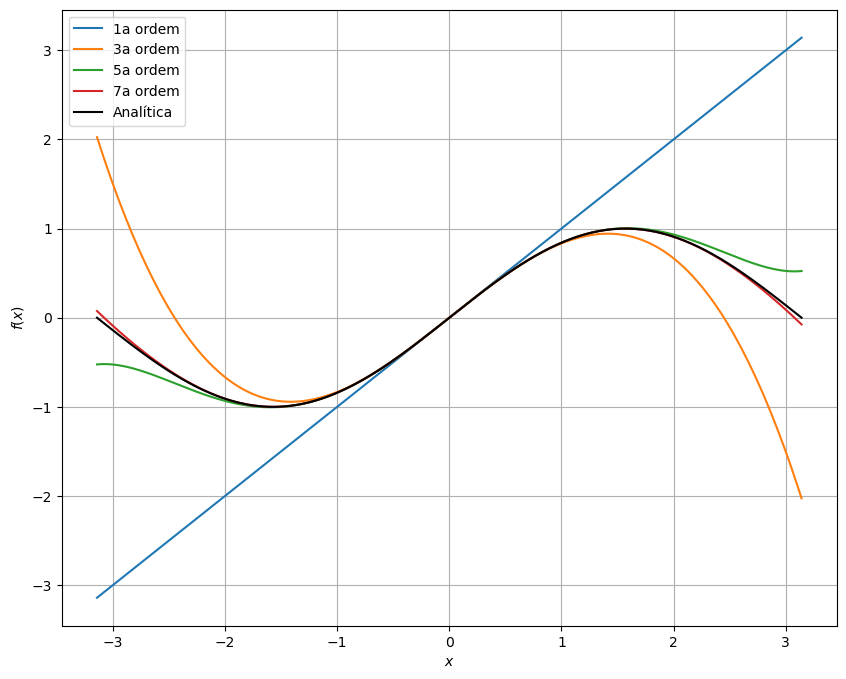

In [21]:
y = np.zeros(len(x))
plt.figure(figsize = (10,8))
for n,label in zip(range(4),['1a ordem', '3a ordem', '5a ordem', '7a ordem']):
    y += T(x,n)
    plt.plot(x,y, label = label)
plt.plot(x, np.sin(x), 'k', label = 'Analítica')
plt.grid()
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.legend()

<div class="alert alert-block alert-info" id="erros">
4. Mensurando erro em métodos numéricos
</div>

Em métodos numéricos, o objetivo principal é encontrar soluções aproximadas para problemas matemáticos, já que muitas vezes as soluções exatas são difíceis ou impossíveis de se obter. Quando trabalhamos com aproximações, é importante medir a precisão dessas soluções, ou seja, o quanto a solução numérica se aproxima da solução exata. Os erros são fundamentais nesse processo, e é comum usar o **erro absoluto** e o **erro relativo** para quantificar essa precisão.

#### Origens dos erros

<img src="figuras/reta.png" width="1000">

#### Erro Absoluto

O **erro absoluto** é a diferença entre o valor exato (ou verdadeiro) de uma grandeza e o valor aproximado obtido por meio de um método numérico. Matematicamente, o erro absoluto $ E_{\text{abs}}$ pode ser definido como:

$$
E_{\text{abs}} = |x_{\text{exato}} - x_{\text{aproximado}}|
$$

Onde:
- $ x_{\text{exato}}$ é o valor exato ou verdadeiro da solução.
- $ x_{\text{aproximado}}$ é o valor obtido pela aproximação numérica.

**Exemplo**: Se, por exemplo, a solução exata de uma equação for $ x_{\text{exato}} = 5$ e o valor aproximado obtido for $ x_{\text{aproximado}} = 4.8$, o erro absoluto seria:

$$
E_{\text{abs}} = |5 - 4.8| = 0.2
$$

**Características do Erro Absoluto**
- Ele fornece uma medida direta da diferença entre o valor exato e o aproximado.
- O erro absoluto é útil quando o valor exato é conhecido e a magnitude do erro precisa ser quantificada diretamente.
- No entanto, o erro absoluto não nos dá uma boa ideia de quão significativo esse erro é em relação ao valor que estamos aproximando, especialmente quando lidamos com números de diferentes ordens de grandeza.

#### Erro Relativo

O **erro relativo** é uma medida que relaciona o erro absoluto com o valor exato. Isso nos permite entender melhor a magnitude do erro em termos da grandeza que estamos tentando aproximar. O erro relativo $ E_{\text{rel}} $ pode ser definido como:

$$
E_{\text{rel}} = \frac{|x_{\text{exato}} - x_{\text{aproximado}}|}{|x_{\text{exato}}|} = \left|1 - \dfrac{x_{\text{aproximado}}}{x_{\text{exato}}}\right|
$$

Ou seja, o erro relativo é o erro absoluto dividido pelo valor exato, o que nos dá uma proporção do erro em relação ao valor verdadeiro.

**Exemplo**: Considerando o mesmo exemplo anterior, onde $ x_{\text{exato}} = 5 $ e $ x_{\text{aproximado}} = 4.8 $, o erro relativo seria:

$$
E_{\text{rel}} = \frac{|5 - 4.8|}{|5|} = \frac{0.2}{5} = 0.04 \quad \text{ou} \quad 4\%
$$

**Características do Erro Relativo**
- O erro relativo é uma medida que normaliza o erro absoluto, oferecendo uma visão mais intuitiva sobre a magnitude do erro em termos da grandeza em questão.
- Ele é especialmente útil quando estamos lidando com valores de grandezas muito grandes ou muito pequenas, pois o erro relativo leva em conta a escala do valor aproximado.
- O erro relativo é frequentemente expresso como uma porcentagem para facilitar a interpretação.

Obviamente, se consideramos um número finito de termos na aproximação por série de Taylor, acabaremos, salvo funções específicas, gerando erros, afinal estamos considerando somente parte de toda a representação. E como em tudo de métodos numéricos, teremos a incidência de erros de **truncamento** e erros de **arredondamento**.

Os erros de arredondamento se devem à inexatidão na representação dos números reais em um computador e nas operações aritméticas feitas com eles. Embora os erros de truncamento sejam devidos à natureza aproximada do método usado, eles geralmente são causados pelo uso de uma aproximação no lugar de um procedimento matemático exato, como o uso da série de Taylor para aproximar uma função.

Por exemplo, considere a função $e^x$:

$$e^x = 1+x+\frac{x^2}{2!} + \frac{x^3}{3!} + \frac{x^4}{4!} + \dots$$

Uma vez que é necessária a sequência infinita para aproximar a função, se pegarmos apenas alguns itens, teremos um erro de truncamento. Por exemplo, se usarmos apenas os primeiros 4 termos para aproximar $e^2$, teremos

$$e^2 \approx 1+2+\frac{2^2}{2!} + \frac{2^3}{3!} = 6.3333$$

que não é o valor mais exato pra representar essa função, se compararmos, por exemplo, com a aproximação feita pela função `np.exp()` da biblioteca Numpy.

Para compararmos isso, podemos usar o código abaixo, gerando a representação de $e^2$ para diferentes ordens e comparando, ao final, com a função `np.exp()`.

In [13]:
exp = 0
x = 2
for i in range(10):
    exp += ((x**i)/math.factorial(i))
    print(f'Usando {i} termo: {exp}')
    
print(f'\nUsando a Numpy: {np.exp(2)}')

Usando 0 termo: 1.0
Usando 1 termo: 3.0
Usando 2 termo: 5.0
Usando 3 termo: 6.333333333333333
Usando 4 termo: 7.0
Usando 5 termo: 7.266666666666667
Usando 6 termo: 7.355555555555555
Usando 7 termo: 7.3809523809523805
Usando 8 termo: 7.387301587301587
Usando 9 termo: 7.3887125220458545

Usando a Numpy: 7.38905609893065


E como mensurar esse erro? Entendendo que, considerando um número $n$ finito de termos da série, teremos

$$ f(x) = f_n(x) + E_n(x) = \sum_{k = 0}^{n} \frac{f^{(k)}(a)(x-a)^k}{k!} + E_n(x)
$$

em que $E_n(x)$ é o erro computado como aprendemos!

No caso aqui, em que "conhecemos" o valor final, podemos obter o erro absoluto diretamente, fazendo

In [23]:
Ea = np.abs(np.exp(2) - 7.3809523809523805)
Ea

0.00810371797826992

E o erro relativo seria

In [24]:
Er = np.abs(1 - 7.3809523809523805/np.exp(2))*100
Er

0.10967189678587896

Ok, mas e quando não conhecemos esse valor que consideramos "real", como proceder? 

> **Calculando a diferença de forma iterativa**

Para calcular o erro relativo iterativo, procedemos como

$$
E_r = \left|\dfrac{x_{anterior} - x_{atual}}{x_{anterior}}\right| = \left|1 - \dfrac{x_{atual}}{x_{anterior}}\right|
$$

#### Cancelamento Catastrófico

O cancelamento catastrófico acontece quando há subtração entre dois números de grandeza similar, fazendo com que os dígitos mais significativos se "anulem". Isso pode resultar em uma perda de precisão muito grande, especialmente em cálculos envolvendo números que são muito próximos um do outro.

Em termos simples, o cancelamento catastrófico ocorre quando uma subtração entre números próximos de grandeza resulta em uma perda de precisão, devido à limitação de dígitos significativos em representações numéricas de ponto flutuante.

Vamos considerar dois casos para verificar a existência desses erros.

**Caso 1**

Considere a função

$$f(x)=\frac{1-\cos(x)}{x^2}.$$

que não é definida em $x=0$, mas, usando a regra de L'Hopital, podemos obter

$$
    \lim_{x \rightarrow 0} \frac{1 - \cos (x)}{x^2} = \lim_{x \rightarrow 0} \frac{\sin (x)}{2 x} = \lim_{x \rightarrow 0} \frac{\cos (x)}{2} = \frac{1}{2}.
$$

Vamos considerar a estimativa desse limite.


In [25]:
f = lambda x:  (1 - np.cos(x))/x**2
x = np.linspace(-5, 5, 100)
y = f(x)
xi = (1.e-5, 1.e-6, 1.e-7, 1.e-8, 1.e-9, 1.e-10, 1.e-11)
for x in xi:
    print('f(',x,')','=',f(x))  

f( 1e-05 ) = 0.5000000413701854
f( 1e-06 ) = 0.5000444502911705
f( 1e-07 ) = 0.4996003610813205
f( 1e-08 ) = 0.0
f( 1e-09 ) = 0.0
f( 1e-10 ) = 0.0
f( 1e-11 ) = 0.0


Esses resultados indicam enganosamente que a função $f$ vai para $0$ quando $x\rightarrow 0$.

Você não pode obter um cálculo preciso devido ao cancelamento catastrófico (ou perda de significância). Para entender o problema, primeiro tenha em mente que os computadores só podem armazenar um número finito de dígitos decimais. Suponha que nossa máquina mantenha apenas 10 dígitos de ponto flutuante (dígitos decimais) e considere o número:
$$a = 0,12345678901234567890.$$

Uma representação de ponto flutuante desse número em nossa máquina seria:
$$b = 0,1234567890$$

Agora execute o cálculo:
$$a - b = 0,00000000001234567890$$

No entanto, na máquina de ponto flutuante de 10 dígitos, o cálculo produz
$$a - b = 0,0000000000$$

Este último número pode ser considerado pela máquina como 0. Portanto, mesmo se dividirmos esse número por algo muito pequeno, ele retornará zero novamente.

> ***Então como resolver esse problema?***

Muitas vezes, podemos resolver reajustando a forma como definimos o problema. 

Vejamos, podemos reescrever nossa função da seguinte forma

$$
\begin{aligned}
f(x)&=\frac{1-\cos(x)}{x^2}\\
&=\frac{(1-\cos(x))(1+\cos(x))}{x^2(1+\cos(x))}\\
&=\frac{1-\cos^2(x)}{x^2(1+\cos(x))}\\
&=\frac{\sin^2(x)}{x^2(1+\cos(x))}\\
\end{aligned}
$$

In [27]:
f = lambda x:  np.sin(x)**2/(x**2*(1+np.cos(x)))
x = np.linspace(-5, 5, 100)
y = f(x)
xi = (1.e-5, 1.e-6, 1.e-7, 1.e-8, 1.e-9, 1.e-10,1.e-11)
for x in xi:
    print('f(',x,')','=',f(x)) 

f( 1e-05 ) = 0.4999999999958333
f( 1e-06 ) = 0.4999999999999583
f( 1e-07 ) = 0.4999999999999995
f( 1e-08 ) = 0.5
f( 1e-09 ) = 0.5
f( 1e-10 ) = 0.5
f( 1e-11 ) = 0.5


**Caso 2**

Vamos considerar um algoritmo instável para o cálculo de $\pi$

- Faça $y=2.0$
- Para $n=1,2,\dots, 30$ 
    - Calcule
$$y=2^{n+1}\sqrt{\frac{1}{2}\left(1-\sqrt{1-(2^{-n}y)^2}\right)}$$
- Retorne $y$ como uma aproximação de $\pi$

In [33]:
yn = 2.0
for n in range(1,31):
    yn=2.0**(n+1) * np.sqrt(0.5*(1.0-np.sqrt(1.0-(2.0**(-n)*yn)**2)))
    print(n, yn) 

1 2.8284271247461903
2 3.0614674589207187
3 3.121445152258053
4 3.1365484905459406
5 3.140331156954739
6 3.141277250932757
7 3.1415138011441455
8 3.1415729403678827
9 3.141587725279961
10 3.141591421504635
11 3.141592345611077
12 3.1415925765450043
13 3.1415926334632482
14 3.141592654807589
15 3.1415926453212153
16 3.1415926073757197
17 3.1415929109396727
18 3.141594125195191
19 3.1415965537048196
20 3.1415965537048196
21 3.1416742650217575
22 3.1418296818892015
23 3.142451272494134
24 3.142451272494134
25 3.1622776601683795
26 3.1622776601683795
27 3.4641016151377544
28 4.0
29 0.0
30 0.0


A sequência parece aproximar $\pi$ até $y_{24}$. Então a computação se torna instável e retorna $0$ devido à perda de significância.

Para evitar a subtração de números quase iguais $a,b\geq 1$, podemos usar a identidade
$(a-b)(a+b)=a^2-b^2$ com
$a=1$ e $b=\sqrt{1-(2^{-n}y_n)^2}$ para obter

$$1-\sqrt{1-(2^{-n}y_n)^2}=\frac{2^{-2n}y_n^2}{1+\sqrt{1-(2^{-n}y_n)^2}}\ .$$

Isso transforma a sequência recursiva em

$$y_{n+1}=\sqrt{\frac{2}{1+\sqrt{1-(2^{-n}y_n)^2}}} y_n\ ,$$

onde novamente $y_1=2$. Implementando a nova iteração recursiva obtemos um algoritmo estável.

In [34]:
yn = 2.0
for n in range(1,31):
    yn=np.sqrt(2.0/(1.0+np.sqrt(1.0-(2.0**(-n)*yn)**2)))*yn
    print(n, yn) 

1 2.8284271247461903
2 3.0614674589207187
3 3.121445152258053
4 3.1365484905459398
5 3.1403311569547534
6 3.1412772509327733
7 3.1415138011443013
8 3.1415729403670913
9 3.1415877252771596
10 3.1415914215111997
11 3.1415923455701176
12 3.1415925765848725
13 3.141592634338563
14 3.141592648776985
15 3.1415926523865907
16 3.1415926532889924
17 3.141592653514593
18 3.141592653570993
19 3.1415926535850933
20 3.141592653588618
21 3.141592653589499
22 3.1415926535897194
23 3.1415926535897745
24 3.1415926535897882
25 3.141592653589792
26 3.1415926535897927
27 3.1415926535897927
28 3.1415926535897927
29 3.1415926535897927
30 3.1415926535897927
